In [4]:
import pandas as pd
import numpy as np
import tenseal as ts
import time
import pickle
import os
import matplotlib.pyplot as plt

# Load PCA Compressed Embeddings

In [5]:
compressed_df = pd.read_csv(
    "../Outputs/Notebook_05/compressed_embeddings.csv"
)

print("Shape:", compressed_df.shape)

compressed_df.head()

Shape: (14446, 128)


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,3.737296,0.673450,0.056452,0.184134,-0.053056,-0.677000,0.585495,-0.260572,-1.047801,-1.826642,...,0.077131,-0.020940,0.142039,-0.762602,-0.168722,0.041406,-0.398751,-0.083328,0.244013,0.100842
1,-1.532914,0.756785,0.850309,0.411241,1.219522,-0.597589,0.299023,0.266456,-0.990097,-1.408628,...,-0.232056,0.191040,0.007581,-0.229094,-0.210753,0.001012,0.079141,-0.041610,-0.143878,0.187849
2,-7.827474,-2.796364,0.439108,1.178336,1.665791,-1.602999,-1.164765,1.155259,0.360561,-0.709616,...,0.168901,0.381731,-0.121816,0.024067,-0.045548,-0.153538,-0.177349,-0.297411,-0.029514,0.005127
3,-0.172677,1.573638,-0.662676,1.244697,1.707050,-0.323209,-0.534795,-1.780205,0.522077,0.491659,...,0.180868,-0.202145,0.122265,-0.299179,0.391831,0.031457,-0.514450,0.020493,0.346794,0.110880
4,0.272627,1.821281,0.401272,2.677169,1.050010,-0.718825,-1.095527,-2.068314,1.696303,0.840766,...,-0.163445,-0.061851,0.021074,-0.272865,-0.002882,0.170077,-0.074081,-0.020336,0.272160,-0.230679


# Analyze Embedding Dataset

In [6]:
print(compressed_df.info())

compressed_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 14446 entries, 0 to 14445
Columns: 128 entries, 0 to 127
dtypes: float64(128)
memory usage: 14.1 MB
None


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
count,1.444600e+04,1.444600e+04,1.444600e+04,1.444600e+04,1.444600e+04,1.444600e+04,1.444600e+04,1.444600e+04,1.444600e+04,1.444600e+04,...,1.444600e+04,1.444600e+04,1.444600e+04,1.444600e+04,1.444600e+04,1.444600e+04,1.444600e+04,1.444600e+04,1.444600e+04,1.444600e+04
mean,1.636914e-15,-2.597027e-15,-1.888747e-16,-2.911818e-16,3.147912e-16,-7.869780e-18,-2.675725e-16,-8.460013e-17,2.006794e-16,1.810049e-16,...,1.364915e-17,3.514349e-16,2.877388e-17,-3.166972e-16,4.311164e-16,1.669254e-16,-1.401805e-17,1.015079e-16,1.486036e-16,-2.754423e-17
std,3.928907e+00,2.426720e+00,1.993540e+00,1.788119e+00,1.691713e+00,1.546540e+00,1.389741e+00,1.375095e+00,1.231110e+00,1.166019e+00,...,2.347499e-01,2.335203e-01,2.316242e-01,2.310345e-01,2.286727e-01,2.282512e-01,2.273133e-01,2.271336e-01,2.241641e-01,2.233203e-01
min,-9.527356e+00,-9.780885e+00,-7.130278e+00,-5.583010e+00,-6.360527e+00,-6.431591e+00,-5.411335e+00,-4.584407e+00,-4.469410e+00,-4.612315e+00,...,-9.107785e-01,-1.049211e+00,-1.086649e+00,-9.898019e-01,-9.505948e-01,-1.233976e+00,-9.605037e-01,-1.147761e+00,-1.399332e+00,-8.473611e-01
25%,-3.229346e+00,-1.149737e+00,-1.306002e+00,-1.239009e+00,-1.025308e+00,-1.031414e+00,-9.061565e-01,-8.814581e-01,-8.387807e-01,-7.780789e-01,...,-1.553803e-01,-1.558183e-01,-1.525606e-01,-1.539280e-01,-1.489529e-01,-1.498330e-01,-1.473097e-01,-1.476961e-01,-1.472476e-01,-1.479489e-01
50%,4.037325e-01,4.759280e-01,7.552467e-02,-4.783083e-02,1.140198e-01,3.057591e-02,3.745288e-02,3.771164e-03,-3.910302e-02,1.293245e-02,...,-9.712295e-04,8.904734e-04,2.304341e-03,1.188682e-03,-1.098623e-03,1.350018e-03,1.632413e-03,4.731451e-04,3.080598e-03,6.553435e-04
75%,3.135596e+00,1.706515e+00,1.396124e+00,1.216759e+00,1.179764e+00,1.075292e+00,9.441013e-01,8.362376e-01,7.883434e-01,7.937415e-01,...,1.524691e-01,1.542229e-01,1.521660e-01,1.542396e-01,1.515467e-01,1.525324e-01,1.480900e-01,1.485985e-01,1.475807e-01,1.471659e-01
max,1.077701e+01,6.408594e+00,6.445501e+00,5.979597e+00,5.599679e+00,5.199175e+00,4.981187e+00,6.209975e+00,4.704077e+00,4.175638e+00,...,1.137819e+00,9.563870e-01,9.399817e-01,9.806072e-01,8.893801e-01,9.390452e-01,1.130541e+00,1.068484e+00,1.197216e+00,1.030508e+00


# Create CKKS Encryption Context

In [7]:
context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[60,40,40,60]
)

context.global_scale = 2**40

context.generate_galois_keys()

context.generate_relin_keys()

print("CKKS Context Created Successfully")

CKKS Context Created Successfully


# Display CKKS Parameters

In [5]:
print("Global Scale:", context.global_scale)

Global Scale: 1099511627776.0


# Extract Image IDs and Feature Vectors

In [7]:
image_names = compressed_df.iloc[:,0]

features = compressed_df.iloc[:,1:].values

print("Feature Shape:", features.shape)

Feature Shape: (14446, 127)


# Visualize Sample Embedding

In [8]:
print(features[0][:20])

[ 0.67344979  0.05645175  0.18413443 -0.05305619 -0.6770001   0.58549486
 -0.26057187 -1.04780067 -1.82664213  2.46699446  0.98109523 -0.72861774
 -0.87973765  0.02364883 -1.07193981  0.26851943 -0.75392665 -0.36529478
 -0.54550582 -1.7211788 ]


# Encrypt Single Sample Embedding

In [9]:
sample_encrypted = ts.ckks_vector(
    context,
    features[0].tolist()
)

print("Sample Encryption Successful")

Sample Encryption Successful


# Analyze Encrypted Template Size

In [10]:
serialized_sample = sample_encrypted.serialize()

print(
    "Encrypted Template Size:",
    len(serialized_sample),
    "bytes"
)

Encrypted Template Size: 334213 bytes


# Encrypt Complete Embedding Dataset

In [11]:
encrypted_embeddings = []

encryption_times = []

for row in features:

    start_time = time.time()

    encrypted_vector = ts.ckks_vector(
        context,
        row.tolist()
    )

    end_time = time.time()

    encrypted_embeddings.append(
        encrypted_vector.serialize()
    )

    encryption_times.append(
        end_time - start_time
    )

print("Dataset Encryption Completed")

Dataset Encryption Completed


# Save Encrypted Templates

In [12]:
os.makedirs(
    "../Outputs/Notebook_06",
    exist_ok=True
)

with open(
    "../Outputs/Notebook_06/encrypted_embeddings.pkl",
    "wb"
) as f:

    pickle.dump(
        encrypted_embeddings,
        f
    )

print("Encrypted Templates Saved")

Encrypted Templates Saved


# Generate Encryption Statistics

In [13]:
stats_df = pd.DataFrame({
    "Image": image_names,
    "Encryption_Time": encryption_times
})

stats_df.to_csv(
    "../Outputs/Notebook_06/encryption_statistics.csv",
    index=False
)

stats_df.head()

,Image,Encryption_Time
0,3.737296,0.007095
1,-1.532914,0.009671
2,-7.827474,0.006776
3,-0.172677,0.005466
4,0.272627,0.008681


# Compute Average Encryption Time

In [14]:
avg_time = np.mean(encryption_times)

print(
    "Average Encryption Time:",
    avg_time,
    "seconds"
)

Average Encryption Time: 0.008087835334335257 seconds


# Memory Usage Analysis

In [15]:
memory_usage = []

for item in encrypted_embeddings:
    memory_usage.append(len(item))

memory_df = pd.DataFrame({
    "Image": image_names,
    "Memory_Bytes": memory_usage
})

memory_df.to_csv(
    "../Outputs/Notebook_06/memory_usage_analysis.csv",
    index=False
)

print(
    "Average Memory Usage:",
    np.mean(memory_usage),
    "bytes"
)

Average Memory Usage: 334289.0094835941 bytes


# Encryption Time Distribution

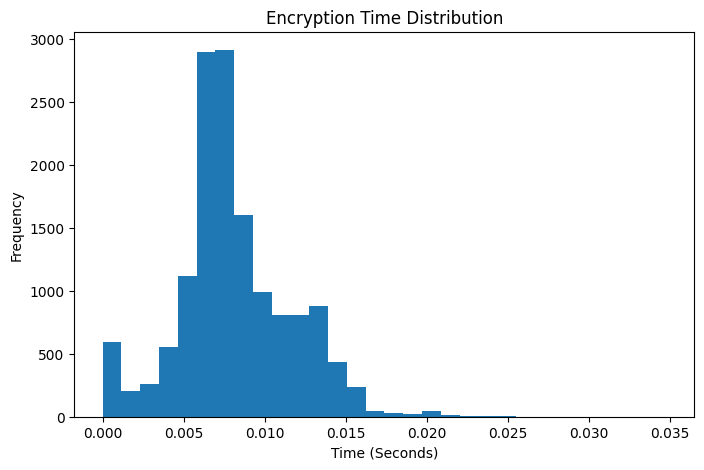

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    encryption_times,
    bins=30
)

plt.title("Encryption Time Distribution")

plt.xlabel("Time (Seconds)")

plt.ylabel("Frequency")

plt.savefig(
    "../Outputs/Notebook_06/encryption_time_distribution.png"
)

plt.show()

# Memory Usage Distribution

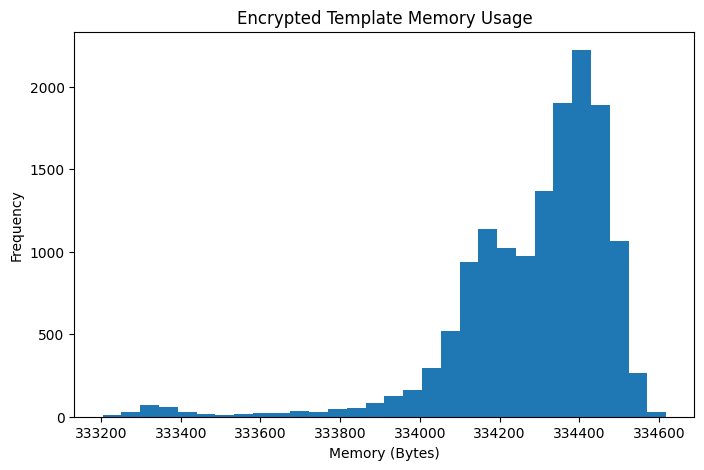

In [17]:
plt.figure(figsize=(8,5))

plt.hist(
    memory_usage,
    bins=30
)

plt.title("Encrypted Template Memory Usage")

plt.xlabel("Memory (Bytes)")

plt.ylabel("Frequency")

plt.savefig(
    "../Outputs/Notebook_06/memory_usage_distribution.png"
)

plt.show()

# Encryption Statistics Summary

In [18]:
summary_df = pd.DataFrame({
    "Metric":[
        "Average Encryption Time",
        "Average Memory Usage"
    ],
    "Value":[
        np.mean(encryption_times),
        np.mean(memory_usage)
    ]
})

summary_df.to_csv(
    "../Outputs/Notebook_06/encryption_summary.csv",
    index=False
)

summary_df

,Metric,Value
0,Average Encryption Time,0.008088
1,Average Memory Usage,334289.009484


In [1]:
import pickle

with open(
    "../Outputs/Notebook_06/encrypted_embeddings.pkl",
    "rb"
) as f:

    encrypted_embeddings = pickle.load(f)

print(type(encrypted_embeddings))
print(len(encrypted_embeddings))

<class 'list'>
14446


# Save CKKS Context

In [8]:
context_bytes = context.serialize(
    save_secret_key=True
)

with open(
    "../Outputs/Notebook_06/context.pkl",
    "wb"
) as f:

    pickle.dump(
        context_bytes,
        f
    )

print("CKKS Context Saved")

CKKS Context Saved


In [9]:
import pickle

with open(
    "../Outputs/Notebook_06/context.pkl",
    "rb"
) as f:

    context_bytes = pickle.load(f)

print(type(context_bytes))

<class 'bytes'>
